In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train['Has_Cabin'] = train['Cabin'].notna().astype(int)
test['Has_Cabin'] = test['Cabin'].notna().astype(int)


In [5]:
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [7]:
age_medians = train.groupby(['Pclass', 'Sex'])['Age'].median()
print(age_medians)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [8]:
def fill_age(row):
    if pd.isnull(row['Age']):
        return age_medians[row['Pclass'], row['Sex']]
    return row['Age']

train['Age'] = train.apply(fill_age, axis=1)

# For test set, compute medians from train (never from test — that's data leakage)
test['Age'] = test.apply(fill_age, axis=1)

In [9]:
print(train['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [11]:
train['Embarked'] = train['Embarked'].fillna('S')
test['Embarked'] = test['Embarked'].fillna('S')

In [12]:
# Extract title from name
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(train['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


In [13]:
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona']

for df in [train, test]:
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(train['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [14]:
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [15]:
for df in [train, test]:
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [16]:
for df in [train, test]:
    df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

In [17]:
drop_cols = ['Name', 'Ticket', 'SibSp', 'Parch', 'Age']
train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols, axis=1, inplace=True)

In [18]:
print(train.columns.tolist())
print(train.head())

['PassengerId', 'Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'Has_Cabin', 'Title', 'FamilySize', 'IsAlone', 'AgeBand']
   PassengerId  Survived  Pclass     Sex     Fare Embarked  Has_Cabin Title  \
0            1         0       3    male   7.2500        S          0    Mr   
1            2         1       1  female  71.2833        C          1   Mrs   
2            3         1       3  female   7.9250        S          0  Miss   
3            4         1       1  female  53.1000        S          1   Mrs   
4            5         0       3    male   8.0500        S          0    Mr   

   FamilySize  IsAlone     AgeBand  
0           2        0  YoungAdult  
1           2        0       Adult  
2           1        1  YoungAdult  
3           2        0  YoungAdult  
4           1        1  YoungAdult  


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Sex', 'Embarked', 'Title', 'AgeBand']

for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.fit_transform(test[col].astype(str))

In [20]:
print(train.head())
print(train.dtypes)

   PassengerId  Survived  Pclass  Sex     Fare  Embarked  Has_Cabin  Title  \
0            1         0       3    1   7.2500         2          0      2   
1            2         1       1    0  71.2833         0          1      3   
2            3         1       3    0   7.9250         2          0      1   
3            4         1       1    0  53.1000         2          1      3   
4            5         0       3    1   8.0500         2          0      2   

   FamilySize  IsAlone  AgeBand  
0           2        0        4  
1           2        0        0  
2           1        1        4  
3           2        0        4  
4           1        1        4  
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int32
Fare           float64
Embarked         int32
Has_Cabin        int32
Title            int32
FamilySize       int64
IsAlone          int32
AgeBand          int32
dtype: object


In [21]:
X = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']

X_test = test.drop(['PassengerId'], axis=1)

print(X.shape, y.shape, X_test.shape)

(891, 9) (891,) (418, 9)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (712, 9)
Validation size: (179, 9)


In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [25]:
test_predictions = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission saved!")

Submission saved!


In [26]:
for df in [train, test]:
    df['FareBand'] = pd.qcut(df['Fare'], 4, labels=[0, 1, 2, 3])

In [27]:
for df in [train, test]:
    df['FamilyGroup'] = pd.cut(df['FamilySize'], 
                                bins=[0, 1, 4, 20], 
                                labels=['Alone', 'Small', 'Large'])
    df['FamilyGroup'] = LabelEncoder().fit_transform(df['FamilyGroup'].astype(str))

In [28]:
for df in [train, test]:
    df['Age_Class'] = df['AgeBand'] * df['Pclass']

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,           # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1       # use all CPU cores
)

grid_search.fit(X, y)  # train on full training data this time

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.8372418555018518


In [38]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("XGB Validation Accuracy:", accuracy_score(y_val, xgb_model.predict(X_val)))

XGB Validation Accuracy: 0.8156424581005587


In [39]:
test_predictions = xgb_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission1.csv', index=False)
print("Done!")

ValueError: feature_names mismatch: ['Pclass', 'Sex', 'Fare', 'Embarked', 'Has_Cabin', 'Title', 'FamilySize', 'IsAlone', 'AgeBand'] ['Pclass', 'Sex', 'Fare', 'Has_Cabin', 'Title', 'FamilySize']
expected IsAlone, Embarked, AgeBand in input data

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV score: 0.8417738999435063


In [41]:
best_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X, y)  # train on FULL training data, not just X_train

test_predictions = best_xgb.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission3.csv', index=False)

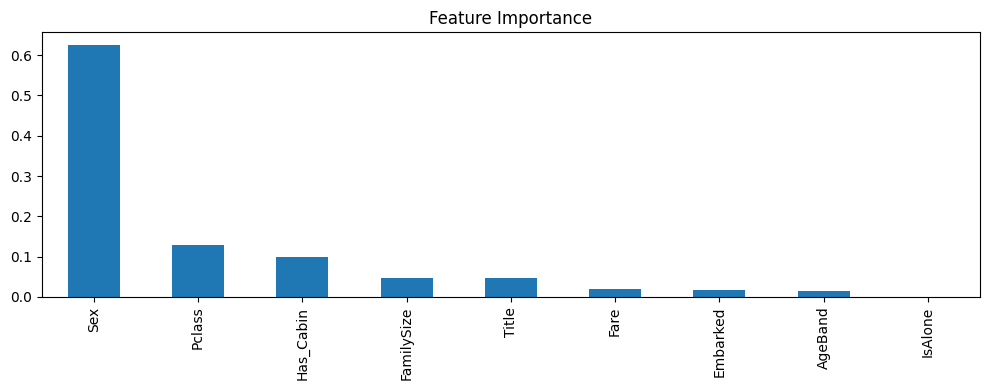

In [36]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_importance.plot(kind='bar', figsize=(10, 4))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [37]:
drop_weak = ['IsAlone', 'AgeBand', 'Embarked']

X = X.drop(drop_weak, axis=1)
X_test = X_test.drop(drop_weak, axis=1)